In [1]:
import os
import itertools
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.stats
from matplotlib import pyplot as plt

import arfcexp.hcp
from skarf import set_cache_dir
from skarf.covariance import load_spi_config_map

In [2]:
pd.options.display.precision = 4

In [3]:
style_path = os.environ["MPL_STYLE"]
print("matplotlib style:", style_path)
plt.style.use(style_path)

color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]

PLOTW, _ = plt.rcParams["figure.figsize"]
FORMAT = plt.rcParams["savefig.format"]
print(PLOTW, FORMAT)

matplotlib style: /ocean/projects/med220004p/clane2/ARFC/arfc-experiments/resources/clane.mplstyle
3.42 png


In [4]:
project_root = Path(os.environ["PROJECT_ROOT"])

pred_perm_result_dir = (
    project_root / "results/hcp_1200_pyspi_behav_prediction_perm_test"
)
pred_baseline_result_dir = (
    project_root / "results/hcp_1200_pyspi_behav_prediction_all_targets_cov"
)
pred_full_result_dir = (
    project_root / "results/hcp_1200_pyspi_behav_prediction_factor_full"
)

pred_analysis_dir = project_root / "results/hcp_1200_pyspi_behav_prediction_analysis"
pred_analysis_dir.mkdir(exist_ok=True)

Load list of SPIs and their metadata.

In [5]:
spi_list_dir = project_root / "resources/spi_lists"
set_cache_dir(spi_list_dir)

spi_config_map, _ = load_spi_config_map()

In [6]:
all_spis = (spi_list_dir / "spi_list_all_284.txt").read_text().strip().split()
print("\n".join(all_spis[:10]))

cov_EmpiricalCovariance
cov_EllipticEnvelope
cov_GraphicalLasso
cov_GraphicalLassoCV
cov_LedoitWolf
cov_MinCovDet
cov_OAS
cov_ShrunkCovariance
cov-sq_EmpiricalCovariance
cov-sq_EllipticEnvelope


In [7]:
spi_id_map = {spi: idx for idx, spi in enumerate(all_spis)}

In [8]:
spi_table = pd.DataFrame.from_records(
    [
        {"spi_id": idx, "spi": spi, **spi_config_map[spi]}
        for idx, spi in enumerate(all_spis)
    ]
)

spi_table.insert(
    2, "category", [module.split(".")[-1] for module in spi_table["module_name"]]
)
spi_table.insert(3, "identifier", [spi.split("_")[0] for spi in spi_table["spi"]])
spi_table = spi_table.drop(columns=["module_name"])

# Make columns categorical to fix order.
for col in ["spi", "category", "identifier"]:
    spi_table[col] = pd.Categorical(
        spi_table[col], categories=spi_table[col].unique(), ordered=True
    )

spi_table.head(4)

,spi_id,spi,category,identifier,fcn,params
0,0,cov_EmpiricalCovariance,basic,cov,Covariance,{'estimator': 'EmpiricalCovariance'}
1,1,cov_EllipticEnvelope,basic,cov,Covariance,{'estimator': 'EllipticEnvelope'}
2,2,cov_GraphicalLasso,basic,cov,Covariance,{'estimator': 'GraphicalLasso'}
3,3,cov_GraphicalLassoCV,basic,cov,Covariance,{'estimator': 'GraphicalLassoCV'}


List of included SPIs.

In [9]:
spi_list = (spi_list_dir / "spi_list_select_300s_142.txt").read_text().strip().split()
print("\n".join(spi_list[:10]))

cov_EmpiricalCovariance
cov_EllipticEnvelope
cov_GraphicalLassoCV
cov_LedoitWolf
cov_MinCovDet
cov_OAS
cov_ShrunkCovariance
spearmanr
kendalltau
xcorr_max_sig-True


Load HCP behavioral columns.

In [10]:
hcp_behav_columns = list(arfcexp.hcp.load_hcp_behav_columns())
hcp_factor_targets = list(arfcexp.hcp.load_hcp_behav_factors_topk())

hcp_factor_order = np.load(
    project_root / "results/hcp_1200_behav/hcp_1200_behav_factor_order.npy"
)
hcp_factor_components = np.load(
    project_root / "results/hcp_1200_behav/hcp_1200_behav_factors.npy"
)

hcp_behav_column_factor_id = np.argmax(np.abs(hcp_factor_components), axis=0)

Misc shared utils.

In [11]:
metric_names = {
    "r2": "$R^2$",
    "corr": "Corr",
    "mse": "MSE",
}

In [12]:
def get_significance(pvalue: float) -> int:
    if pvalue < 0.001:
        return 3
    if pvalue < 0.01:
        return 2
    if pvalue < 0.05:
        return 1
    return 0

### Permutation test analysis

Estimate the empirical null distribution using the prediction results with permuted test labels.

- 1 SPI (empirical covariance) x 4 target factors
- 200 splits = 800 rows

In [13]:
perm_result_paths = sorted(pred_perm_result_dir.rglob("results.json"))
print("Num perm test result files:", len(perm_result_paths))

perm_results = pd.concat([pd.read_json(path, lines=True) for path in perm_result_paths])

print("Perm test result table shape:", perm_results.shape)

Num perm test result files: 4
Perm test result table shape: (800, 18)


In [14]:
perm_results.head(5)

,spi,target,parc_size,pool,n_splits,perm_test,seed,split,n_train,n_test,alpha,r2_train,r2_val,r2_test,mse_train,mse_test,corr_train,corr_test
0,cov_EmpiricalCovariance,Cognition,200,3,200,True,6275,0,693,174,100.0,0.0045,-0.0094,-0.0228,0.9955,0.8799,0.3633,0.0398
1,cov_EmpiricalCovariance,Cognition,200,3,200,True,6275,1,704,163,3.0,0.1223,-0.0018,-0.0036,0.8777,1.0360,0.5580,0.0375
2,cov_EmpiricalCovariance,Cognition,200,3,200,True,6275,2,700,167,100.0,0.0042,-0.0132,-0.0056,0.9958,0.8424,0.4658,-0.0270
3,cov_EmpiricalCovariance,Cognition,200,3,200,True,6275,3,705,162,20.0,0.0285,-0.0070,-0.0086,0.9715,0.9845,0.3453,-0.0772
4,cov_EmpiricalCovariance,Cognition,200,3,200,True,6275,4,705,162,100.0,0.0042,-0.0085,-0.0101,0.9958,0.8579,0.3806,-0.0337


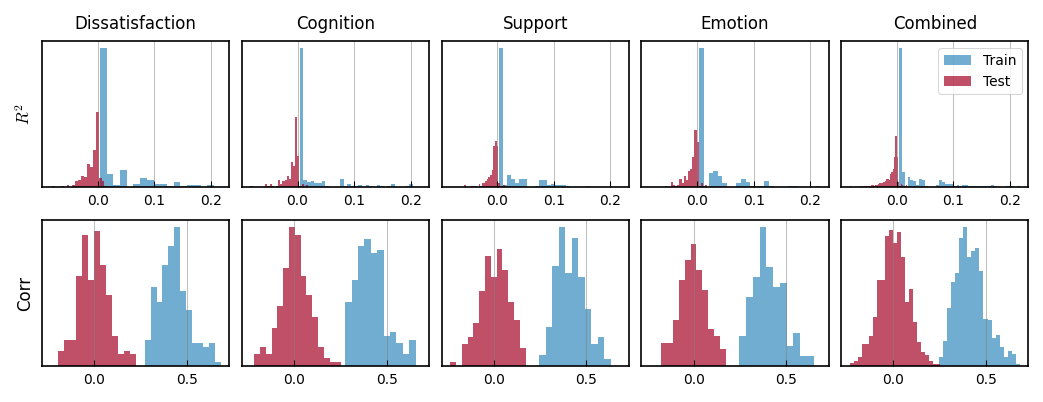

In [15]:
f, axs = plt.subplots(
    2,
    5,
    figsize=(2 * PLOTW, 0.75 * PLOTW),
    layout="constrained",
    sharex="row",
)

n_bins = "auto"

for ii, metric in enumerate(["r2", "corr"]):
    for jj in range(5):
        ax = axs[ii, jj]
        plt.sca(ax)

        if jj < 4:
            target = hcp_factor_targets[jj]
            sub_perm_results = perm_results.query(f"target == '{target}'")
        else:
            target = "Combined"
            sub_perm_results = perm_results

        plt.hist(
            sub_perm_results[f"{metric}_train"], bins=n_bins, alpha=0.7, label="Train"
        )
        plt.hist(
            sub_perm_results[f"{metric}_test"], bins=n_bins, alpha=0.7, label="Test"
        )

        plt.yticks([])

        if ii == 0:
            plt.title(target, fontsize="medium")

        if jj == 0:
            plt.ylabel(metric_names[metric], fontsize="medium")

        if ii == 0 and jj == 4:
            plt.legend(loc="upper right")

f.savefig(
    pred_analysis_dir / f"perm_test_metric_histograms.{FORMAT}", bbox_inches="tight"
)

Check that none of the distributions are different, to justify combining the null distributions.

In [16]:
perm_dist_comparisons = []

for target_1, target_2 in itertools.product(hcp_factor_targets, hcp_factor_targets):
    if target_1 == target_2:
        continue

    for metric in ["r2", "corr"]:
        x1 = perm_results.loc[
            perm_results["target"] == target_1, f"{metric}_test"
        ].values
        x2 = perm_results.loc[
            perm_results["target"] == target_2, f"{metric}_test"
        ].values
        stat, pval = scipy.stats.mannwhitneyu(x1, x2)
        perm_dist_comparisons.append(
            {
                "target_1": target_1,
                "target_2": target_2,
                "metric": metric,
                "stat": stat,
                "pval": pval,
            }
        )

perm_dist_comparisons = pd.DataFrame.from_records(perm_dist_comparisons)

perm_dist_comparisons.groupby("metric").agg({"pval": ["count", "min", "median", "max"]})

pval                        
       count     min  median     max
metric                              
corr      12  0.1497  0.3633  0.7929
r2        12  0.2348  0.5453  0.9886

Nb, these p-values are uncorrected for the multiple comparisons. Safe to say the distributions are not reliably different. Fine to combine as one null distribution.

### Empirical covariance baseline on all targets

here we get the baseline prediction performance of empirical covariance on all the targets (and also see which are reliably predictable).

- 1 spi (empirical covariance) x (55 measures + 4 factors)
- 20 splits = 1180 rows

In [17]:
baseline_result_paths = sorted(pred_baseline_result_dir.rglob("results.json"))
print("Num baseline test result files:", len(baseline_result_paths))

baseline_results = pd.concat(
    [pd.read_json(path, lines=True) for path in baseline_result_paths]
)

print("Baseline test result table shape:", baseline_results.shape)

Num baseline test result files: 59
Baseline test result table shape: (1180, 18)


In [18]:
baseline_results.head(5)

,spi,target,parc_size,pool,n_splits,perm_test,seed,split,n_train,n_test,alpha,r2_train,r2_val,r2_test,mse_train,mse_test,corr_train,corr_test
0,cov_EmpiricalCovariance,AngAffect_Unadj,200,3,20,False,3293,0,684,183,2.0,0.1765,0.0060,-0.0048,0.8235,1.0429,0.6104,0.0461
1,cov_EmpiricalCovariance,AngAffect_Unadj,200,3,20,False,3293,1,698,169,2.5,0.1429,0.0067,0.0202,0.8571,0.8364,0.5940,0.1653
2,cov_EmpiricalCovariance,AngAffect_Unadj,200,3,20,False,3293,2,694,173,2.0,0.1806,0.0150,-0.0070,0.8194,1.0698,0.5934,0.0488
3,cov_EmpiricalCovariance,AngAffect_Unadj,200,3,20,False,3293,3,697,170,100.0,0.0053,-0.0010,-0.0022,0.9947,1.2042,0.4770,0.2412
4,cov_EmpiricalCovariance,AngAffect_Unadj,200,3,20,False,3293,4,684,183,2.0,0.1766,0.0055,-0.0077,0.8234,1.3694,0.5972,0.0616


Test for significant prediction compared to empirical null distribution.

In [19]:
baseline_two_sample_comparisons = []

for target in hcp_factor_targets + hcp_behav_columns:
    for metric in ["r2", "corr"]:
        null_values = perm_results[f"{metric}_test"].values
        values = baseline_results.loc[
            baseline_results["target"] == target, f"{metric}_test"
        ].values

        stat, pval = scipy.stats.mannwhitneyu(
            values, null_values, alternative="greater"
        )
        baseline_two_sample_comparisons.append(
            {"target": target, "metric": metric, "stat": stat, "pval": pval}
        )

baseline_two_sample_comparisons = pd.DataFrame.from_records(
    baseline_two_sample_comparisons
)
baseline_two_sample_comparisons = baseline_two_sample_comparisons.set_index(
    ["target", "metric"]
)

baseline_two_sample_comparisons.head()

stat        pval
target          metric                     
Dissatisfaction r2      11235.0  9.9581e-04
                corr    13943.0  6.7451e-09
Cognition       r2      16000.0  1.0384e-14
                corr    16000.0  1.0384e-14
Support         r2      10018.0  2.6909e-02

In [20]:
def plot_baseline_boxplots_factors(metric="r2"):
    f, ax = plt.subplots(
        1, 1, figsize=(0.75 * PLOTW, 0.75 * PLOTW), layout="constrained"
    )

    data = []
    labels = []
    colors = []

    # Bonferroni correction for the number of targets.
    num_comparisons = len(hcp_factor_targets)

    for ii, target in enumerate(hcp_factor_targets):
        values = baseline_results.loc[
            baseline_results["target"] == target, f"{metric}_test"
        ].values
        pvalue = baseline_two_sample_comparisons.loc[(target, metric), "pval"]

        label = target[:20]
        sig_level = get_significance(pvalue * num_comparisons)
        if sig_level:
            label = f"({sig_level * '∗'}) {label}"  # nb center asterisk

        data.append(values)
        labels.append(label)
        colors.append(color_cycle[ii])

    pos = np.arange(len(data))
    bplot = plt.boxplot(
        data, positions=pos, patch_artist=True, medianprops={"color": "k"}
    )

    # fill with colors
    for patch, color in zip(bplot["boxes"], colors):
        patch.set_facecolor(color)

    plt.ylabel(metric_names[metric], fontsize="medium")
    plt.xticks(pos, labels, rotation=45, fontsize="small", ha="right")
    return f

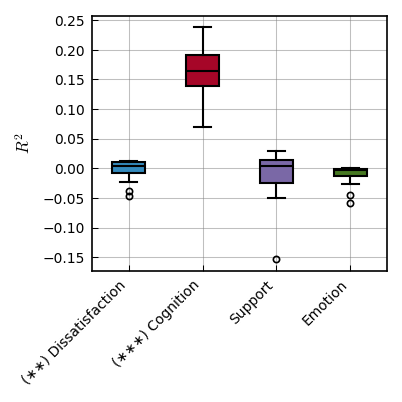

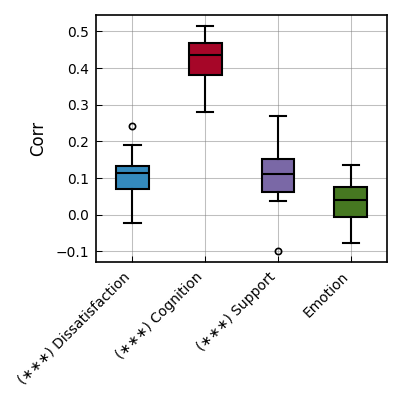

In [21]:
for metric in ["r2", "corr"]:
    f = plot_baseline_boxplots_factors(metric)
    f.savefig(
        pred_analysis_dir / f"baseline_prediction_boxplots_factors_{metric}.{FORMAT}",
        bbox_inches="tight",
    )

In [22]:
# boxplot of prediction scores for HCP behavioral measures


def plot_baseline_boxplots_measures(metric="r2"):
    f, ax = plt.subplots(1, 1, figsize=(2 * PLOTW, 0.75 * PLOTW), layout="constrained")

    data = []
    labels = []
    colors = []

    # Bonferroni correction for the number of targets.
    num_comparisons = len(hcp_behav_columns)

    for idx in hcp_factor_order:
        target = hcp_behav_columns[idx]
        values = baseline_results.loc[
            baseline_results["target"] == target, f"{metric}_test"
        ].values
        pvalue = baseline_two_sample_comparisons.loc[(target, metric), "pval"]

        label = target[:20]
        sig_level = get_significance(pvalue * num_comparisons)
        if sig_level:
            label = f"({sig_level * '∗'}) {label}"  # nb center asterisk

        data.append(values)
        labels.append(label)
        colors.append(color_cycle[hcp_behav_column_factor_id[idx]])

    pos = np.arange(len(data))
    bplot = plt.boxplot(
        data, positions=pos, patch_artist=True, medianprops={"color": "k"}
    )

    # fill with colors
    for patch, color in zip(bplot["boxes"], colors):
        patch.set_facecolor(color)

    plt.ylabel(metric_names[metric], fontsize="medium")
    plt.xticks(pos, labels, rotation=90, fontsize="x-small")
    return f

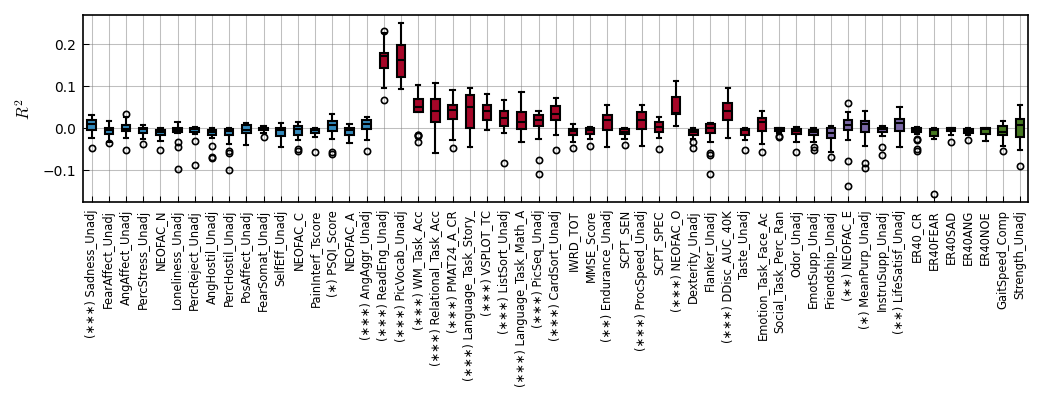

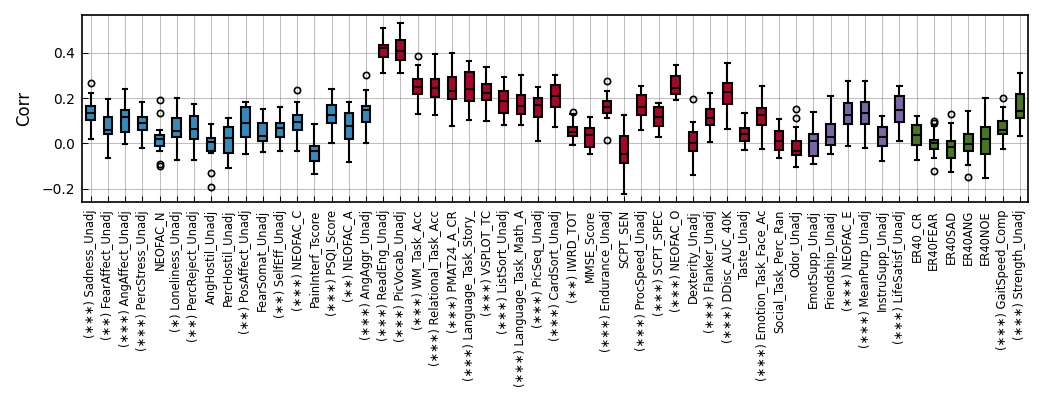

In [23]:
for metric in ["r2", "corr"]:
    f = plot_baseline_boxplots_measures(metric)
    f.savefig(
        pred_analysis_dir / f"baseline_prediction_boxplots_measures_{metric}.{FORMAT}",
        bbox_inches="tight",
    )

### All SPIs on four factors

Finally we compare all PySPI SPIs on the four factors.

Although we have four factors, we'll focus on just cognition since that is the most predictable factor.

- (142 SPIs - 1 failed) x 4 factors = 564 files
- 20 splits = 11280 rows 

In [24]:
full_result_paths = sorted(pred_full_result_dir.rglob("results.json"))
print("Num full test result files:", len(full_result_paths))

full_results = pd.concat([pd.read_json(path, lines=True) for path in full_result_paths])

full_results["spi"] = pd.Categorical(
    full_results["spi"], categories=spi_list, ordered=True
)

full_results = spi_table.loc[:, ["spi", "spi_id", "category", "identifier"]].merge(
    full_results, on="spi", how="right"
)

print("Full test result table shape:", full_results.shape)

Num full test result files: 564


Full test result table shape: (11280, 21)


In [25]:
full_results.head(5)

,spi,spi_id,category,identifier,target,parc_size,pool,n_splits,perm_test,seed,...,n_train,n_test,alpha,r2_train,r2_val,r2_test,mse_train,mse_test,corr_train,corr_test
0,cov_EmpiricalCovariance,0,basic,cov,Cognition,200,3,20,False,2142,...,697,170,0.4,0.5694,0.1343,0.1598,0.4306,0.6487,0.8291,0.4032
1,cov_EmpiricalCovariance,0,basic,cov,Cognition,200,3,20,False,2142,...,700,167,0.4,0.5615,0.1282,0.2070,0.4385,0.9000,0.8250,0.4718
2,cov_EmpiricalCovariance,0,basic,cov,Cognition,200,3,20,False,2142,...,702,165,0.4,0.5697,0.1686,0.1288,0.4303,0.8373,0.8313,0.3956
3,cov_EmpiricalCovariance,0,basic,cov,Cognition,200,3,20,False,2142,...,701,166,0.4,0.5565,0.1309,0.2489,0.4435,0.6998,0.8234,0.5171
4,cov_EmpiricalCovariance,0,basic,cov,Cognition,200,3,20,False,2142,...,711,156,0.4,0.5603,0.1348,0.2128,0.4397,0.8469,0.8253,0.4705


In [26]:
full_results_agg = full_results.groupby(
    ["category", "identifier", "spi", "target"], observed=True
).agg({"split": "count", "r2_test": "median", "corr_test": "median"})

full_results_agg.head(10)

split  r2_test  \
category identifier spi                     target                            
basic    cov        cov_EllipticEnvelope    Cognition           20   0.1703   
                                            Dissatisfaction     20   0.0044   
                                            Emotion             20  -0.0068   
                                            Support             20   0.0114   
                    cov_EmpiricalCovariance Cognition           20   0.1613   
                                            Dissatisfaction     20   0.0008   
                                            Emotion             20  -0.0083   
                                            Support             20   0.0024   
                    cov_GraphicalLassoCV    Cognition           20   0.1275   
                                            Dissatisfaction     20  -0.0050   

                                                             corr_test  
category identifier spi                     target                      
basic    cov        cov_EllipticEnvelope    Cognition           0.4183  
                                            Dissatisfaction     0.1020  
                                            Emotion             0.0227  
                                            Support             0.1365  
                    cov_EmpiricalCovariance Cognition           0.4088  
                                            Dissatisfaction     0.0887  
                                            Emotion             0.0159  
                                            Support             0.1168  
                    cov_GraphicalLassoCV    Cognition           0.3634  
                                            Dissatisfaction     0.0113

Test for significant prediction compared to empirical null distribution, and difference compared to baseline.

In [27]:
full_two_sample_comparisons = []

for spi in spi_list:
    for target in hcp_factor_targets:
        for metric in ["r2", "corr"]:
            null_values = perm_results[f"{metric}_test"].values
            baseline_values = baseline_results.loc[
                baseline_results["target"] == target, f"{metric}_test"
            ].values

            values = full_results.query(f"spi == '{spi}' and target == '{target}'")[
                f"{metric}_test"
            ].values

            if len(values):
                null_stat, null_pval = scipy.stats.mannwhitneyu(
                    values, null_values, alternative="greater"
                )
                baseline_stat, baseline_pval = scipy.stats.mannwhitneyu(
                    values, baseline_values
                )

            else:
                null_stat = null_pval = baseline_stat = baseline_pval = np.nan

            full_two_sample_comparisons.append(
                {
                    "spi": spi,
                    "target": target,
                    "metric": metric,
                    "reference": "null",
                    "stat": null_stat,
                    "pval": null_pval,
                }
            )
            full_two_sample_comparisons.append(
                {
                    "spi": spi,
                    "target": target,
                    "metric": metric,
                    "reference": "baseline",
                    "stat": baseline_stat,
                    "pval": baseline_pval,
                }
            )

full_two_sample_comparisons = pd.DataFrame.from_records(full_two_sample_comparisons)
full_two_sample_comparisons = full_two_sample_comparisons.set_index(
    ["spi", "target", "metric", "reference"]
)

In [28]:
full_two_sample_comparisons.head(8)

stat        pval
spi                     target          metric reference                     
cov_EmpiricalCovariance Dissatisfaction r2     null       10503.0  8.3819e-03
                                               baseline     171.0  4.4075e-01
                                        corr   null       12540.0  7.1640e-06
                                               baseline     159.0  2.7329e-01
                        Cognition       r2     null       16000.0  1.0384e-14
                                               baseline     187.0  7.3527e-01
                                        corr   null       15999.0  1.0461e-14
                                               baseline     178.0  5.6085e-01

In [29]:
spi_category_colors = {
    category: color_cycle[ii]
    for ii, category in enumerate(full_results["category"].unique())
}

In [30]:
def plot_full_boxplots_spis(
    target: str = "Cognition", metric: str = "r2", topk: int = 2
):
    # correct for the number of SPI comparisons
    num_comparisons = len(spi_list)

    # empirical covariance baseline score
    baseline_score = baseline_results.loc[
        baseline_results["target"] == target, f"{metric}_test"
    ].median()

    # spi families in correct order; hack
    cat_identifier_list = list(
        {
            (cat, identifier): None
            for cat, identifier in zip(
                full_results["category"], full_results["identifier"]
            )
        }
    )

    data = []
    labels = []
    colors = []

    # Get top-k spis for each spi family
    for category, identifier in cat_identifier_list:
        topk_values = (
            full_results_agg.loc[
                pd.IndexSlice[:, identifier, :, target], f"{metric}_test"
            ]
            .sort_values(ascending=False)
            .head(topk)
        )

        topk_spis = list(topk_values.index.get_level_values(2))
        color = spi_category_colors[category]

        for spi in topk_spis:
            values = full_results.query(f"spi == '{spi}' and target == '{target}'")[
                f"{metric}_test"
            ].values
            score = np.median(values)

            null_pval, baseline_pval = full_two_sample_comparisons.loc[
                (spi, target, metric, slice(None)), "pval"
            ]

            label = f"({spi_id_map[spi] + 1:03d}) {spi[:18]}"

            # (·): not significantly > null
            # (<): significantly < baseline
            # (~): not significantly different from baseline
            if not get_significance(null_pval * num_comparisons):
                label = f"(·) {label}"
            elif get_significance(baseline_pval * num_comparisons):
                label = f"({'<' if score < baseline_score else '>'}) {label}"
            else:
                label = f"(~) {label}"

            data.append(values)
            labels.append(label)
            colors.append(color)

    f, ax = plt.subplots(1, 1, figsize=(2 * PLOTW, 0.75 * PLOTW), layout="constrained")

    pos = np.arange(len(data))
    bplot = plt.boxplot(
        data,
        positions=pos,
        patch_artist=True,
        medianprops={"color": "k"},  # , flierprops={"clip_on": False}
    )

    # fill with colors
    for patch, color in zip(bplot["boxes"], colors):
        patch.set_facecolor(color)

    plt.ylabel(metric_names[metric], fontsize="medium")
    plt.xticks(pos, labels, rotation=90, fontsize="xx-small")
    plt.axhline(baseline_score, color="r", alpha=0.5)

    ymin, ymax = plt.ylim()
    ymax = ymin + 1.1 * (ymax - ymin)
    plt.ylim(ymin, ymax)

    # dummy bars for legend
    for category, color in spi_category_colors.items():
        plt.bar([0], [0], width=0, color=color, edgecolor="none", label=category)
    plt.legend(loc="upper center", ncol=7, fontsize="x-small")

    return f

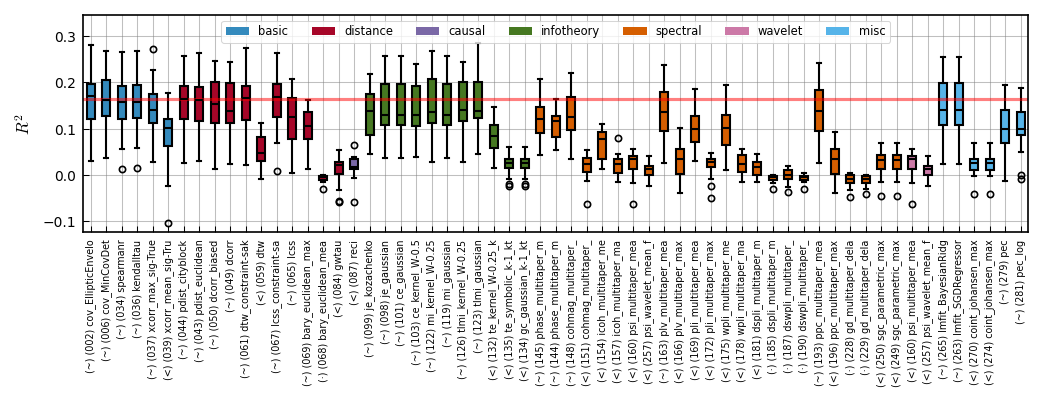

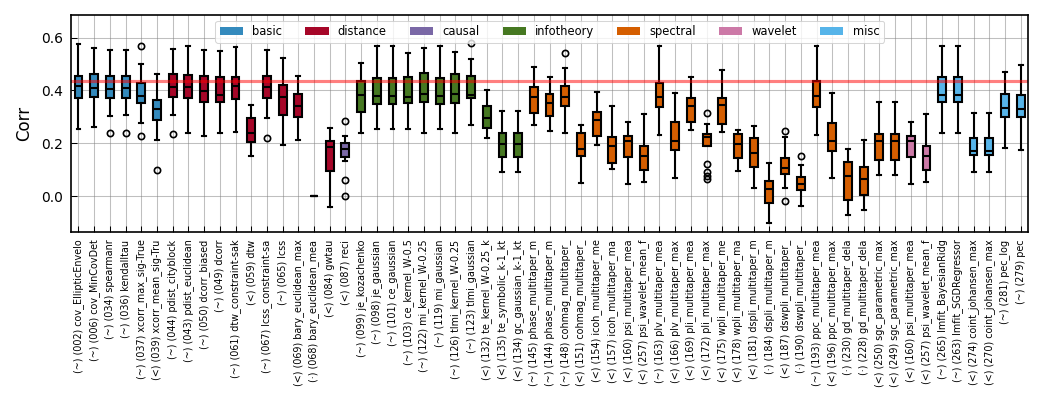

In [31]:
target = "Cognition"

for metric in ["r2", "corr"]:
    f = plot_full_boxplots_spis(target=target, metric=metric)
    f.savefig(
        pred_analysis_dir / f"full_prediction_boxplots_{target}_{metric}.{FORMAT}",
        bbox_inches="tight",
    )